### Deatiled pipeline

In [1]:
%load_ext autoreload
%autoreload 2
from scripts.utils.data_loader import create_configs, load_data
from scripts.utils.preprocessing import lof_outlier_removal
from scripts.utils.post_processing import save_results, compute_fold_shap, plot_shap_summary

from scipy.stats import randint, uniform, loguniform

from sklearn.preprocessing import PowerTransformer

from imblearn import FunctionSampler

from functools import partial
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import mutual_info_classif

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE, SMOTENC

from sklearn.compose import ColumnTransformer

from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV, cross_validate

from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

import shap

import os
import numpy as np
import pandas as pd

In [2]:
class CorrelationBasedFeatureSelection(BaseEstimator, TransformerMixin):
    def __init__(self, intercorr_threshold=0.90, target_corr_threshold=0.25):
        self.intercorr_threshold = intercorr_threshold
        self.target_corr_threshold = target_corr_threshold
        self.to_drop_intercorrelated_ = []
        self.to_drop_target_corr_ = []
        self.to_drop_ = []
        self.selected_features_ = []

    def fit(self, X, y):
        X_df = pd.DataFrame(X) if isinstance(X, np.ndarray) else X
        y_series = pd.Series(y) if isinstance(y, np.ndarray) else y
        
        corr_matrix = X_df.corr().abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        target_corr = X_df.apply(lambda col: col.corr(y_series)).abs()
        
        drop_intercorr_set = set()
        for col in upper_tri.columns:
            for row in upper_tri.index:
                if upper_tri.loc[row, col] > self.intercorr_threshold:
                    if row not in drop_intercorr_set and col not in drop_intercorr_set:
                        if target_corr[row] >= target_corr[col]:
                            drop_intercorr_set.add(col)
                        else:
                            drop_intercorr_set.add(row)
        
        self.to_drop_intercorrelated_ = list(drop_intercorr_set)

        X_reduced = X_df.drop(columns=self.to_drop_intercorrelated_, errors='ignore')
        target_corr_reduced = target_corr.loc[X_reduced.columns]
        n_reduced = len(target_corr_reduced)
        n_keep = int(np.ceil(self.target_corr_threshold * n_reduced))

        self.selected_features_ = (
            target_corr_reduced
            .sort_values(ascending=False)
            .head(n_keep)
            .index
            .tolist()
        )

        to_drop_target_corr_ = [
            col for col in X_reduced.columns
            if col not in self.selected_features_
        ]

        self.to_drop_target_corr_ = to_drop_target_corr_
        self.to_drop_ = self.to_drop_intercorrelated_ + self.to_drop_target_corr_

        return self

    def transform(self, X):
        X_df = pd.DataFrame(X) if isinstance(X, np.ndarray) else X.copy()
        X_selected = X_df.drop(columns=self.to_drop_, errors='ignore')
        return X_selected.values if isinstance(X, np.ndarray) else X_selected

    def set_output(self, transform):
        return self

In [ ]:
# Setup experiment configurations
case_idx = 8
model_name = "RF"
feature_set = "eGeMAPS_Demographics"
feature_selector_method = "rfe"

N_REPEATS = 10
OUTER_SPLITS = 10
INNER_SPLITS = 10
N_ITER = 3
TOTAL_OUTER_FITS = N_REPEATS * OUTER_SPLITS
ALLOCATED_CPUS = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 1))

n_dict = {
    "n_repeats": N_REPEATS,
    "outer_splits": OUTER_SPLITS,
    "inner_splits": INNER_SPLITS,
    "n_iter": N_ITER,
    "outer_verbose": 20,
    "inner_verbose": 1,
    "outer_n_jobs": min(ALLOCATED_CPUS, TOTAL_OUTER_FITS),
    "inner_n_jobs": 1
}

config = create_configs(case_idx, model_name, feature_set, feature_selector_method, n_dict)
out_dir = f"../results_tests/{model_name}_{feature_selector_method}/sex={config['sexes_key']}/task={config['tasks_key']}"
config.update({"out_dir": out_dir})
os.makedirs(out_dir, exist_ok=True)

# Load data
X, y, groups, num_cols, cat_cols = load_data(config)

# Define scoring metrics
scoring = {
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "average_precision": "average_precision",
    "f1": "f1"
}

# Build pipeline
yj_pt = PowerTransformer(method="yeo-johnson", standardize=True)
if feature_set == "eGeMAPS_Demographics":
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", yj_pt, num_cols),
            ("cat", "passthrough", cat_cols)
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )
    
    cat_indices = list(range(len(num_cols), len(num_cols) + len(cat_cols)))
    oversampler = SMOTENC(categorical_features=cat_indices, random_state=42)
else:
    preprocessor = yj_pt
    oversampler = SMOTE(random_state=42)

lof_sampler = FunctionSampler(
    func=lof_outlier_removal,
    kw_args={
        "contamination": 0.05,
        "n_neighbors": 20,
        "algorithm": "auto",
        "metric": "manhattan",
    },
    validate=False,
)

if config["feature_selector_method"] == "mi_based":
    feature_selector = SelectPercentile(score_func=partial(mutual_info_classif, n_neighbors=5, random_state=42))

elif config["feature_selector_method"] == "corr_based":
    feature_selector = CorrelationBasedFeatureSelection()

elif config["feature_selector_method"] == "rfe":
    feature_selector = RFE(estimator=RandomForestClassifier(n_estimators=25, random_state=42), step = 0.1)

elif config["feature_selector_method"] == "passthrough":
    feature_selector = "passthrough"

clf = RandomForestClassifier(class_weight=None, n_jobs=1, random_state=42)

steps = [
    ("preprocessor", preprocessor),
    ("outlier_removal", lof_sampler),
    ("oversampler", oversampler),
    ("feature_selector", feature_selector),
    ("classifier", clf),
]

pipeline = ImbPipeline(steps=steps).set_output(transform="pandas")

# Param distributions for RandomizedSearchCV
param_distributions = {}
if feature_selector_method == "mi_based":
    param_distributions.update({
        "feature_selector__percentile": randint(50, 91),  # [50, 90]
    })

elif feature_selector_method == "corr_based":
    param_distributions.update({
        "feature_selector__intercorr_threshold": uniform(0.85, 0.1),  # [0.85, 0.95]
        "feature_selector__target_corr_threshold": uniform(0.2, 0.1),  # [0.2, 0.3]
    })

elif feature_selector_method == "rfe":
    param_distributions.update({
        "feature_selector__n_features_to_select": uniform(0.1, 0.9),  # [0.1, 1.0]
    })

param_distributions.update({
    "oversampler__k_neighbors": randint(3, 8),  # [3, 7]
    "classifier__n_estimators": randint(200, 1001),  # [200, 1000]
    "classifier__max_depth": randint(3, 21),  # [3, 20]
    "classifier__max_features": ["sqrt", "log2", 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    "classifier__min_samples_split": uniform(0.05, 0.45),  # [0.05, 0.5]
    "classifier__min_samples_leaf": uniform(0.01, 0.19),  # [0.01, 0.2]
    "classifier__ccp_alpha": loguniform(1e-6, 1e-1),
})

# Setup cross-validation
outer_splits = []
for i in range(config["n_repeats"]):
    sgkf = StratifiedGroupKFold(
        n_splits=config["outer_splits"],
        shuffle=True,
        random_state=42+i
    )
    outer_splits.extend(list(sgkf.split(X, y, groups)))

inner_cv = StratifiedGroupKFold(
    n_splits=config["inner_splits"],
    shuffle=True,
    random_state=42
)

# Setup hyperparameter tuning
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=config["n_iter"],
    scoring="roc_auc",
    n_jobs=config["inner_n_jobs"],
    cv=inner_cv,
    verbose=config["inner_verbose"],
    random_state=42,
    refit=True,
    error_score='raise'
)

# Execute nested cross-validation
results = cross_validate(
    search,
    X=X,
    y=y,
    params={'groups': groups},
    cv=outer_splits,
    scoring=scoring,
    return_estimator=True,
    n_jobs=config["outer_n_jobs"],
    pre_dispatch=config["outer_n_jobs"],
    verbose=config["outer_verbose"],
    error_score='raise'
)

In [5]:
# DataFrame of results with best parameters
results_df = pd.DataFrame(results).drop(columns=["estimator"])
params_df = pd.DataFrame.from_records(est.best_params_ for est in results["estimator"])

if config["model_name"] == "GB":
    params_df["classifier__n_estimators"] = [
        est.best_estimator_.named_steps["classifier"].n_estimators_ for est in results["estimator"]
    ]
elif config["model_name"] == "MLP":
    classifiers = [
        est.best_estimator_.named_steps["classifier"]
        for est in results["estimator"]
    ]
    params_df["classifier__loss"] = [
        getattr(clf, "loss_", None)
        for clf in classifiers
    ]
    params_df["classifier__best_loss"] = [
        getattr(clf, "best_loss_", None)
        for clf in classifiers
    ]
    params_df["classifier__best_validation_score"] = [
        getattr(clf, "best_validation_score_", None)
        for clf in classifiers
    ]
    params_df["classifier__n_iter"] = [
        getattr(clf, "n_iter_", None)
        for clf in classifiers
    ]

results_df = pd.concat([results_df.reset_index(drop=True), params_df.reset_index(drop=True)], axis=1)
results_df = results_df.sort_values("test_roc_auc", ascending=False)
# results_df.to_csv(f"{out_dir}/results.csv", index=False)

# Summary statistics of metrics
scoring_statistics_df = pd.DataFrame({
    k: results[f"test_{v}"] for k, v in scoring.items()
}).agg(["mean", "std"]).T
scoring_statistics_df.to_csv(f"{out_dir}/scoring_statistics.csv", index=True)

# Outer CV results
n_outer = config["outer_splits"]
n_total = config["outer_splits"] * config["n_repeats"]
outer_df = pd.DataFrame({
    "repeat": (np.arange(n_total) // n_outer) + 1,
    "outer_fold": (np.arange(n_total) % n_outer) + 1,
    **{k: results[f"test_{v}"] for k, v in scoring.items()}
})
# outer_df.to_csv(f"{out_dir}/outer_cv_results.csv", index=False)

if config["model_name"] != "MLP":
    inner_df = pd.DataFrame([
        {
            "repeat": (i // config["outer_splits"]) + 1,
            "outer_fold": (i % config["outer_splits"]) + 1,
            "inner_best_score": est.best_score_,
            "inner_best_params": est.best_params_,
            "selected_features": list(est.best_estimator_.named_steps["feature_selector"].get_feature_names_out()) if config["feature_selector_method"] != "passthrough" else "passthrough",
            "n_selected_features": len(list(est.best_estimator_.named_steps["feature_selector"].get_feature_names_out())) if config["feature_selector_method"] != "passthrough" else "passthrough"
        }
        for i, est in enumerate(results["estimator"])
    ])
    # inner_df.to_csv(f"{out_dir}/inner_cv_results.csv", index=False)

else:
    inner_df = pd.DataFrame([
        {
            "repeat": (i // config["outer_splits"]) + 1,
            "outer_fold": (i % config["outer_splits"]) + 1,
            "inner_best_score": est.best_score_,
            "inner_best_params": est.best_params_,
            "selected_features": list(est.best_estimator_.named_steps["feature_selector"].get_feature_names_out()) if config["feature_selector_method"] != "passthrough" else "passthrough",
            "n_selected_features": len(list(est.best_estimator_.named_steps["feature_selector"].get_feature_names_out())) if config["feature_selector_method"] != "passthrough" else "passthrough"
        }
        for i, est in enumerate(results["estimator"])
    ])

    loss_validation_df = pd.DataFrame([
        {
            "repeat": (i // config["outer_splits"]) + 1,
            "outer_fold": (i % config["outer_splits"]) + 1,
            "iteration": iteration + 1,
            "loss": loss,
            "validation_score": score
        }
        for i, clf in enumerate(classifiers)
        for iteration, (loss, score) in enumerate(zip(getattr(clf, "loss_curve_", []), getattr(clf, "validation_scores_", [])))
    ])
    
    # inner_df.to_csv(f"{out_dir}/inner_cv_results.csv", index=False)
    # loss_validation_df.to_csv(f"{out_dir}/loss_validation_curves.csv", index=False)

# if config["feature_selector_method"] == "corr_based":
    #     inner_df = pd.DataFrame([
    #         {
    #             "repeat": (i // config["outer_splits"]) + 1,
    #             "outer_fold": (i % config["outer_splits"]) + 1,
    #             "inner_best_score": est.best_score_,
    #             "inner_best_params": est.best_params_,
    #             "selected_features": list(est.best_estimator_.named_steps["feature_selector"].selected_features_),
    #             "n_selected_features": len(list(est.best_estimator_.named_steps["feature_selector"].selected_features_))
    #         }
    #         for i, est in enumerate(results["estimator"])
    #     ])
    # else:


In [ ]:
from joblib import Parallel, delayed
def _compute_single_fold_shap(fold_idx, train_idx, val_idx, search_estimator, model_name, X, config):
    """Helper function to compute SHAP values for a single fold."""
    
    shap_background_fraction = 1/4
    shap_eval_fraction = 1/3
    shap_background_min = 50 
    shap_background_max = 100 
    shap_eval_min = 50 
    shap_eval_max = 100 

    best_estimator = search_estimator.best_estimator_

    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    # Drop only the classifier. The resulting ImbPipeline will automatically 
    # skip the 'oversampler' and 'outlier_removal' when you call preprocessor.transform(X)
    preprocessor = best_estimator[:-1] 

    # Extract the classifier
    classifier = best_estimator[-1]
    
    
    # preprocessor = best_estimator[:-2]  # Exclude oversampling and classifier
    # classifier = best_estimator[-1]

    X_train_trans = preprocessor.transform(X_train_fold)
    X_val_trans = preprocessor.transform(X_val_fold)

    selected_features_names = X_train_trans.columns.tolist()
    all_features_names = X.columns.tolist()

    # Determine the number of background samples for SHAP
    n_background = min(
        len(X_train_trans),
        max(shap_background_min, int(np.ceil(len(X_train_trans) * shap_background_fraction))),
        shap_background_max
    )

    # Sample evaluation data for SHAP from the transformed validation set
    n_eval = min(
        len(X_val_trans),
        max(shap_eval_min, int(np.ceil(len(X_val_trans) * shap_eval_fraction))),
        shap_eval_max,
    )
    
    X_val_trans_sampled = X_val_trans.sample(
        n=n_eval,
        random_state=42 + fold_idx,
    )

    # Compute SHAP values based on the model type
    if model_name in ["DT", "RF", "GB", "XGB", "LGBM"]:    
        background = X_train_trans.sample(
            n=n_background,
            random_state=42 + fold_idx
        )
        explainer = shap.TreeExplainer(
            classifier,
            data=background,
            model_output="probability",
            feature_perturbation="interventional",
        )
        shap_values = explainer.shap_values(X_val_trans_sampled, check_additivity=False)
    
    elif model_name in ["SVC", "MLP"]:
        background = shap.kmeans(
            X_train_trans,
            n_background
        )
        explainer = shap.KernelExplainer(
            lambda X_batch: classifier.predict_proba(
                pd.DataFrame(X_batch, columns=selected_features_names)
            )[:, 1],
            background
        )
        shap_values = explainer.shap_values(
            X_val_trans_sampled,
            nsamples=2 * X_val_trans_sampled.shape[1] + 512,
            silent=True
        )
    
    else:
        raise ValueError(f"Model {model_name} is unsupported for SHAP computation.")
    
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1] if shap_values.shape[2] > 1 else shap_values[:, :, 0]
    
    shap_df = pd.DataFrame(0.0, index=X_val_trans_sampled.index, columns=all_features_names)
    shap_df.loc[:, selected_features_names] = pd.DataFrame(
        shap_values,
        index=X_val_trans_sampled.index,
        columns=selected_features_names,
    )
    
    return shap_df

def compute_fold_shap(outer_splits, results, model_name, X, y, config, n_jobs=-1):
    """
    Compute SHAP values per outer fold in parallel.
    """
    os.makedirs(config["out_dir"], exist_ok=True)
    
    all_shap_dfs = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(_compute_single_fold_shap)(
            fold_idx, train_idx, val_idx, search_estimator, model_name, X, config
        )
        for fold_idx, ((train_idx, val_idx), search_estimator) in enumerate(zip(outer_splits, results['estimator']))
    )

    total_shap_df = pd.concat(all_shap_dfs, axis=0)
    shap_df_avg = total_shap_df.groupby(total_shap_df.index).mean()

    # shap_df_avg.to_csv(f"{config['out_dir']}/shap_values_avg_{config['model_name']}.csv")
    # total_shap_df.to_csv(f"{config['out_dir']}/shap_values_all_{config['model_name']}.csv")

    return all_shap_dfs, total_shap_df, shap_df_avg

In [20]:
all_shap_dfs, total_shap_df, shap_df_avg = compute_fold_shap(
    outer_splits=outer_splits,
    results=results,
    model_name=config["model_name"],
    X=X,
    y=y,
    config=config,
    n_jobs=config["outer_n_jobs"]
)

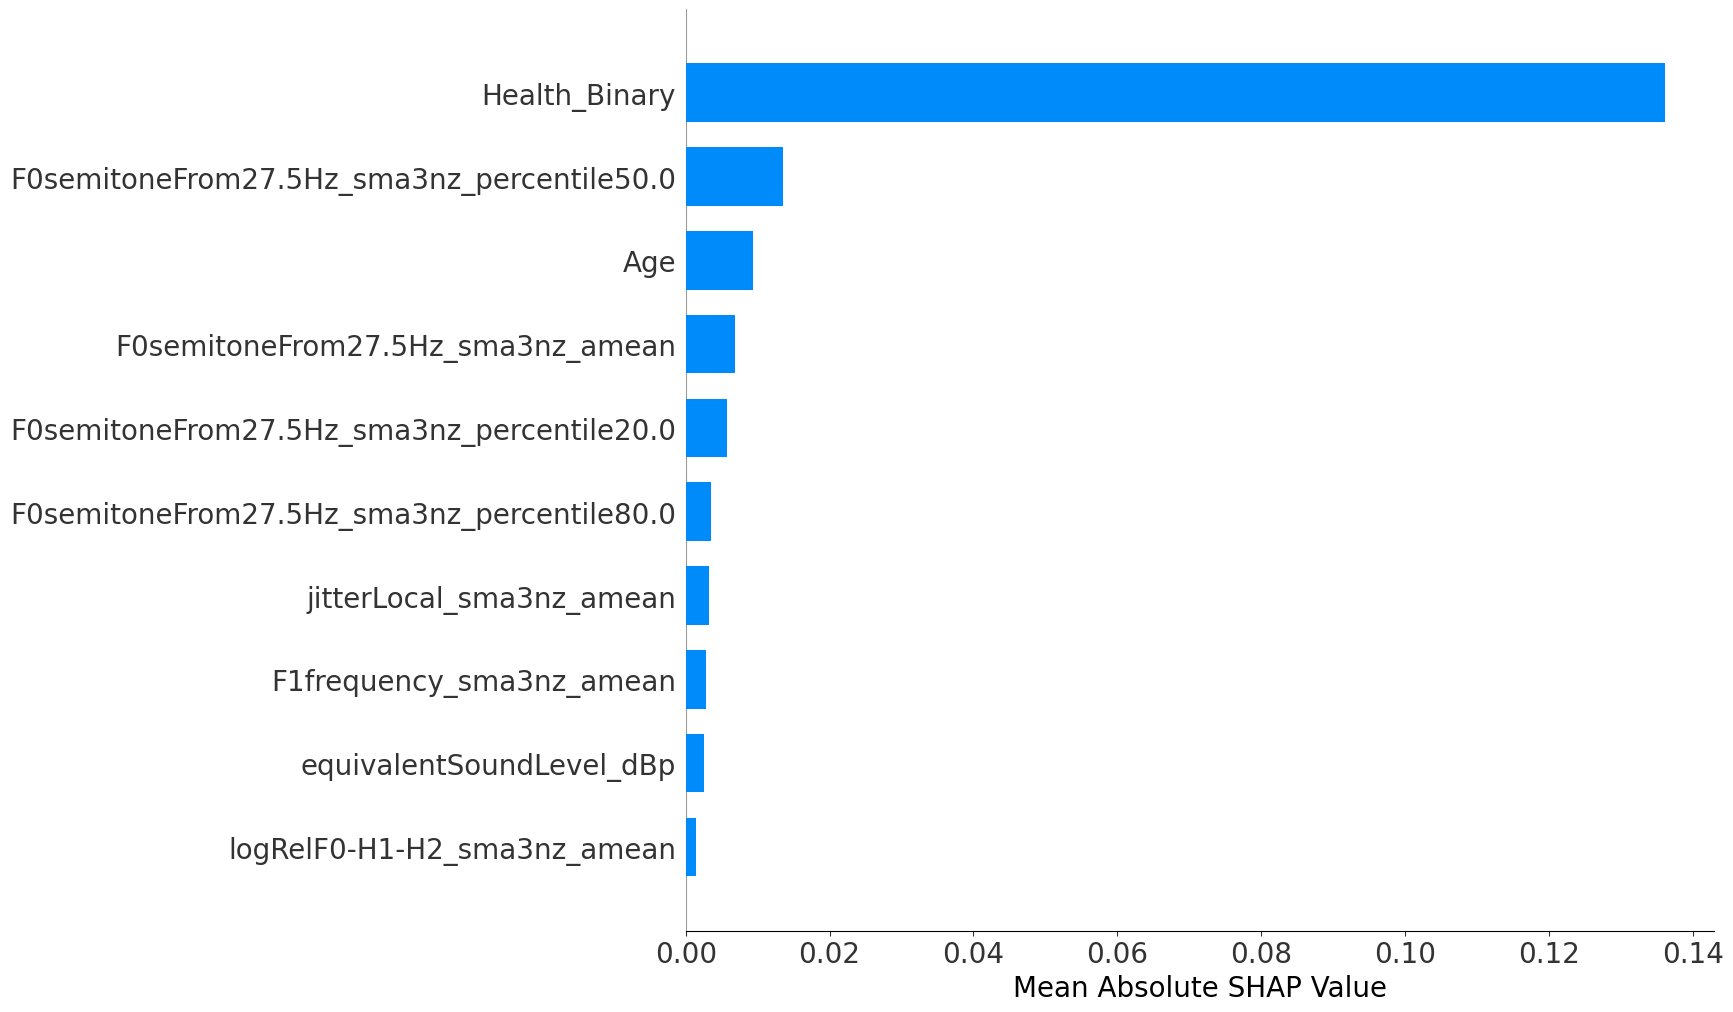

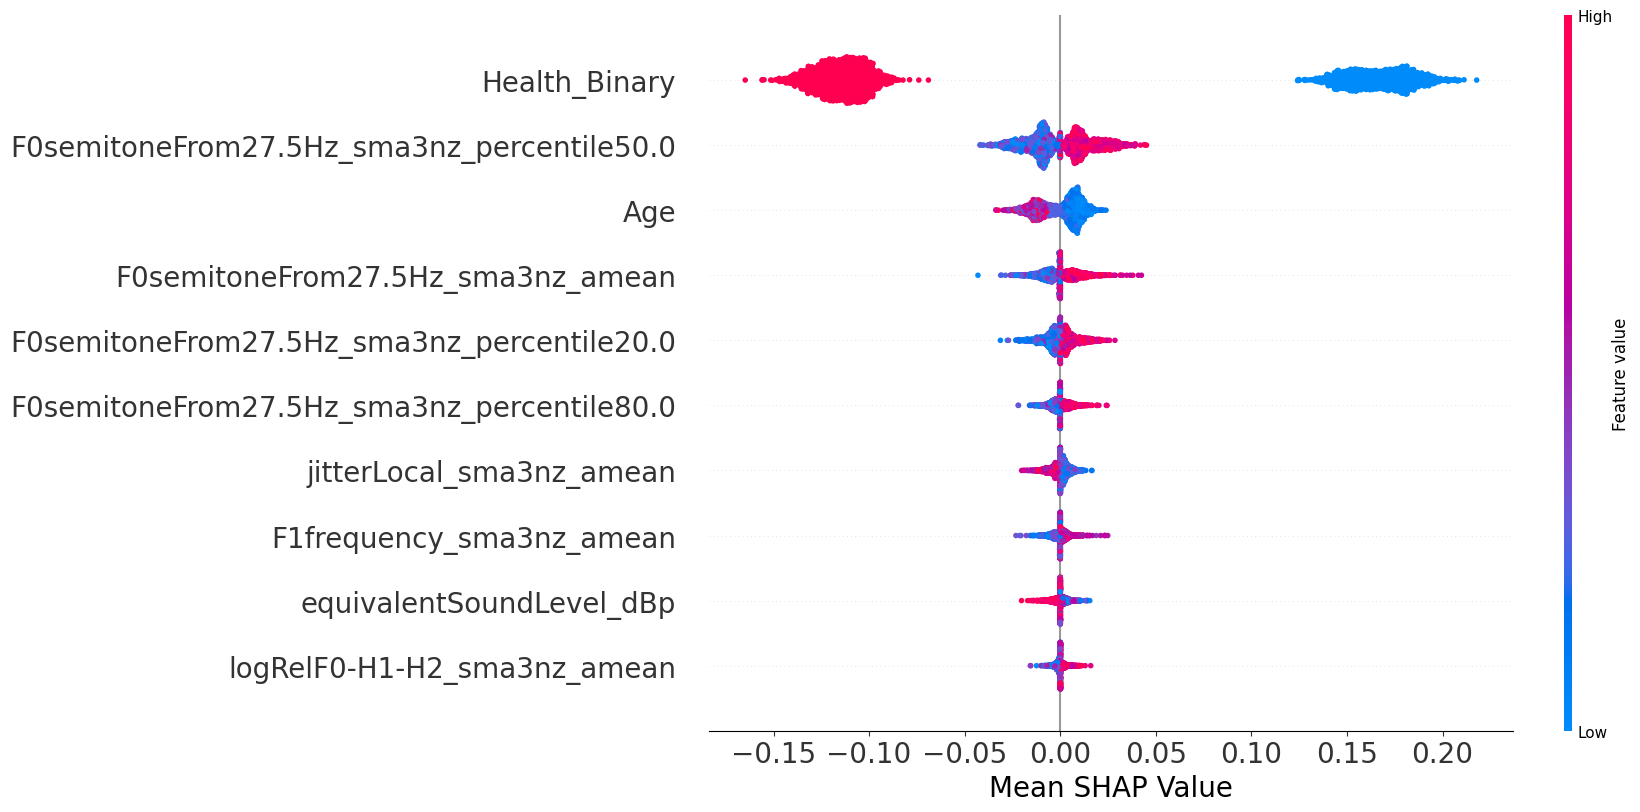

In [ ]:
import matplotlib.pyplot as plt
os.makedirs(config["out_dir"], exist_ok=True)
X_shap = X.loc[shap_df_avg.index]

# Bar plot
fig = shap.summary_plot(
    shap_df_avg.values,
    X_shap,
    plot_type="bar",
    show=False,
    max_display=10,
    plot_size=(15, 10)
)
ax = plt.gca()
ax.set_xlabel("Mean Absolute SHAP Value", fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
plt.setp(ax.get_xticklabels(), fontsize=20)
plt.setp(ax.get_yticklabels(), fontsize=20)
plt.show()
# plt.savefig(f"{config['out_dir']}/SHAP_summary_bar_plot_{config['model_name']}.png", bbox_inches='tight')
# plt.close()

# Dot plot
fig = shap.summary_plot(
    shap_df_avg.values,
    X_shap,
    plot_type="dot",
    show=False,
    max_display=10,
    plot_size=(15, 8)
)
ax = plt.gca()
ax.set_xlabel("Mean SHAP Value", fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
plt.setp(ax.get_xticklabels(), fontsize=20)
plt.setp(ax.get_yticklabels(), fontsize=20)
plt.show()
# plt.savefig(f"{config['out_dir']}/SHAP_summary_dot_plot_{config['model_name']}.png", bbox_inches='tight')
# plt.close()

In [ ]:
os.makedirs(config["out_dir"], exist_ok=True)

shap_background_fraction = 1/4
shap_eval_fraction = 1/3

shap_background_min = 50 # 25 or 100 or 200
shap_background_max = 100 # 50 or 200 or 1000

shap_eval_min = 50 # 12 or 50
shap_eval_max = 100 # 25 or 100 or 500

all_shap_dfs = []
for fold_idx, ((train_idx, val_idx), search_estimator) in enumerate(zip(outer_splits, results['estimator'])):
    best_estimator = search_estimator.best_estimator_

    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    preprocessor = best_estimator[:-2]  # Exclude oversampling and classifier
    classifier = best_estimator[-1]

    X_train_trans = preprocessor.transform(X_train_fold)
    X_val_trans = preprocessor.transform(X_val_fold)

    selected_features_names = X_train_trans.columns.tolist()
    all_features_names = X.columns.tolist()

    # Determine the number of background samples for SHAP
    n_background = min(
        len(X_train_trans),
        max(shap_background_min, int(np.ceil(len(X_train_trans) * shap_background_fraction))),
        shap_background_max
    )

    # Sample evaluation data for SHAP from the transformed validation set
    n_eval = min(
        len(X_val_trans),
        max(shap_eval_min, int(np.ceil(len(X_val_trans) * shap_eval_fraction))),
        shap_eval_max,
    )
    X_val_trans_sampled = X_val_trans.sample(
        n=n_eval,
        random_state=42 + fold_idx,
    )

    # Compute SHAP values based on the model type
    if model_name in ["DT", "RF", "GB", "XGB", "LGBM"]:    
        background = X_train_trans.sample(
            n=n_background,
            random_state=42 + fold_idx
        )
        explainer = shap.TreeExplainer(
            classifier,
            data=background,
            model_output="probability",
            feature_perturbation="interventional",
        )
        shap_values = explainer.shap_values(X_val_trans_sampled, check_additivity=False)
    
    elif model_name == "SVC":
        background = shap.kmeans(
            X_train_trans,
            n_background
        )
        explainer = shap.KernelExplainer(
            classifier.decision_function, 
            background
        )
        shap_values = explainer.shap_values(
            X_val_trans_sampled,
            nsamples=2*X_val_trans_sampled.shape[1]+512
        )
    
    elif model_name == "MLP":
        background = shap.kmeans(
            X_train_trans,
            n_background
        )
        explainer = shap.KernelExplainer(
            lambda X_batch: classifier.predict_proba(
                pd.DataFrame(X_batch, columns=selected_features_names)
            )[:, 1],
            background,
        )
        shap_values = explainer.shap_values(
            X_val_trans_sampled,
            nsamples=2 * X_val_trans_sampled.shape[1] + 512,
        )
    
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1] if shap_values.shape[2] > 1 else shap_values[:, :, 0]
    
    shap_df = pd.DataFrame(0.0, index=X_val_trans_sampled.index, columns=all_features_names)
    shap_df.loc[:, selected_features_names] = pd.DataFrame(
        shap_values,
        index=X_val_trans_sampled.index,
        columns=selected_features_names,
    )
    all_shap_dfs.append(shap_df)

total_shap_df = pd.concat(all_shap_dfs, axis=0)
shap_df_avg = total_shap_df.groupby(total_shap_df.index).mean()

shap_df_avg.to_csv(f"{config['out_dir']}/shap_values_avg_{config['model_name']}.csv")
total_shap_df.to_csv(f"{config['out_dir']}/shap_values_all_{config['model_name']}.csv")

In [ ]:
all_shap_dfs, total_shap_df, shap_df_avg = compute_fold_shap(outer_splits, results, model_name, X, y, config)

In [6]:
plot_shap_summary(shap_df_avg, X, config)